# Librerias

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import torch
# from torch import nn
# from torch.utils.data import Dataset, DataLoader
# from torchvision import datasets, transforms
# import random

# seed = 42
# random.seed(seed)
# np.random.seed(seed)
# torch.manual_seed(seed)
# torch.cuda.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using {device} device")

Using cpu device


In [1]:
# 1.1)
import os
import pickle
import datetime
from collections import defaultdict

Test para saber si PyTorch reconoce la GPU

- Aclaración: `torch`, `torchvision`, `torchaudio`, `torchviz` están instalados <u>localmente</u> en el `venv`.

In [2]:
import torch
import numpy as np 
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

2.9.1+cu130
True
NVIDIA GeForce GTX 1650
cuda


In [3]:
# 1.2)
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import sklearn as skl
import pandas as pd
import random
#import dill
import json

In [4]:
# 1.3)
# import torch
import torch.optim as optim
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms import ToTensor, Lambda, Compose
#from torchviz import make_dot

In [5]:
# Extra
from tqdm.notebook import tqdm
import time
from sklearn.metrics import ConfusionMatrixDisplay

# Datos

## Datasets

In [6]:
class CustomDataset(Dataset):
    def __init__(self,dataset):
        self.dataset=dataset
    # Redefinimos el método .__len__()
    def __len__(self):
        return len(self.dataset)
    # Redefinimos el método .__getitem__()
    def __getitem__(self,i):
        image,label=self.dataset[i]
        input  = image
        output = image # Retornamos la imagen como salida
        return input, output

In [7]:
transform = transforms.ToTensor() # Para pasar de imágene PIL a tensores
train_set_orig = datasets.FashionMNIST('MNIST_data/', download = True, train = True,  transform = transform)
valid_set_orig = datasets.FashionMNIST('MNIST_data/', download = True, train = False, transform = transform)
train_set = CustomDataset(train_set_orig)
valid_set = CustomDataset(valid_set_orig)

## Diccionario de Clases

In [8]:
class_names = {
    0: "T-shirt/top", # Remera manga corta o top
    1: "Trouser",     # Pantalón
    2: "Pullover",    # Buzo
    3: "Dress",       # Vestido
    4: "Coat",        # Abrigo
    5: "Sandal",      # Sandalia
    6: "Shirt",       # Camisa
    7: "Sneaker",     # Zapatilla
    8: "Bag",         # Bolso
    9: "Ankle boot"   # Bota
}

## Visualización de los Datos

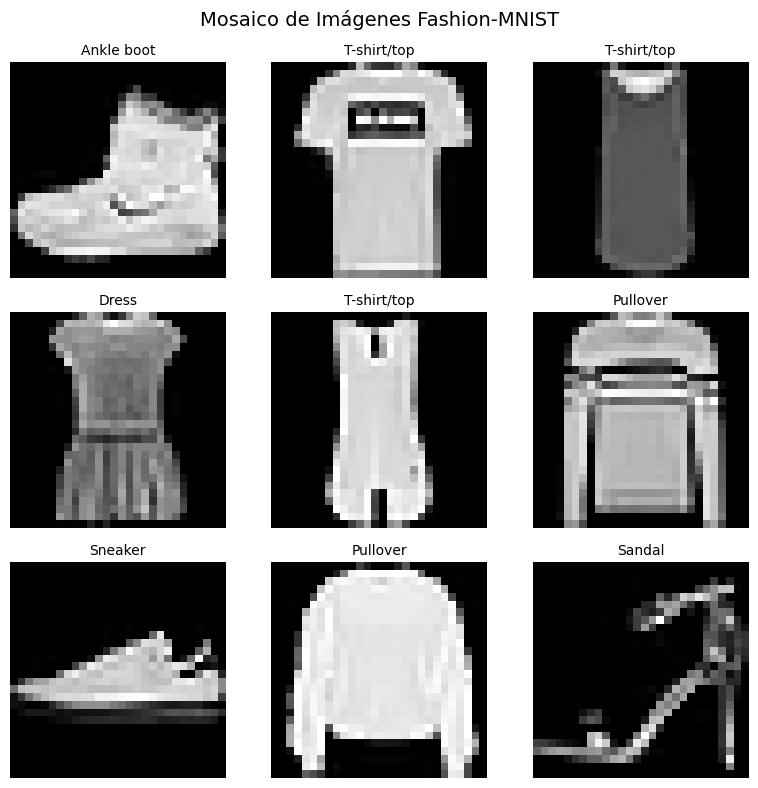

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i in range(3):
  for j in range(3) :
    index = i * 3 + j
    image, label = train_set_orig[index]
    axes[i, j].imshow(image.squeeze(), cmap='gray')
    axes[i, j].set_title(class_names[label], fontsize=10)
    axes[i, j].axis('off')

plt.suptitle("Mosaico de Imágenes Fashion-MNIST", fontsize=14)
plt.tight_layout()
plt.show()

# Autoencoder

In [10]:
# 4.1)
class AutoencoderConvolutional(nn.Module):
    """
    Autoencoder convolucional profundo para imágenes Fashion-MNIST (1x28x28),
    compuesto por un módulo codificador convolucional, un cuello de botella
    opcional completamente conectado y un decodificador convolucional transpuesto.

    Parameters
    ----------
    p1 : float, optional
        Probabilidad de dropout aplicada al final del codificador convolucional.
        Controla el nivel de regularización (default = 0.2).

    p2 : float, optional
        Probabilidad de dropout aplicada en el cuello de botella completamente conectado.
        Permite regularizar el espacio latente. Por defecto no se aplica dropout (default = 0.0).

    n : int, optional
        Dimensión del espacio latente en el cuello de botella fully-connected.
        Determina el grado de compresión de la representación (default = 128).

    filter_num1 : int, optional
        Número de filtros de la primera convolución del encoder.
        Define la profundidad inicial del mapa de características
        (default = 8).

    filter_num2 : int, optional
        Número de filtros de la segunda convolución del encoder.
        Aumenta la capacidad representacional del modelo antes del pooling
        (default = 16).

    ks1 : int, optional
        Tamaño del kernel de la primera convolución del encoder (default = 3).

    ks2 : int, optional
        Tamaño del kernel de la segunda convolución del encoder (default = 3).
      
    ks3 : int, optional
        Tamaño del kernel de la primera convolución transpuesta del decoder (default = 2).

    ks4 : int, optional
        Tamaño del kernel de la segunda convolución transpuesta del decoder (default = 5).

    str1 : int, optional
        Stride de la primera convolución del encoder (default = 1).

    str2 : int, optional
        Stride de la segunda convolución del encoder (default = 1).

    str3 : int, optional
        Stride de la primera convolución transpuesta del decoder (default = 2).

    str4 : int, optional
        Stride de la segunda convolución transpuesta del decoder (default = 1).

    pad1 : int, optional
        Padding de la primera convolución del encoder (default = 0).

    pad2 : int, optional
        Padding de la segunda convolución del encoder (default = 0).

    pad3 : int, optional
        Padding de la primera convolución transpuesta del decoder (default = 0).

    pad4 : int, optional
        Padding de la segunda convolución transpuesta del decoder (default = 0).

    dil1 : int, optional
        Dilatación de la primera convolución del encoder (default = 1).

    dil2 : int, optional
        Dilatación de la segunda convolución del encoder (default = 1).

    dil3 : int, optional
        Dilatación de la primera convolución transpuesta del decoder (default = 1).

    dil4 : int, optional
        Dilatación de la segunda convolución transpuesta del decoder (default = 1).

    pool_size : tuple of int, optional
        Tamaño del max-pooling aplicado luego de la convolución del encoder.
        Reduce la resolución espacial de los mapas de características
        (default = (2, 2)).

    use_bn : bool, optional
        Indica si se utiliza un cuello de botella lineal completamente conectado.
        Si True, se incluye una capa fully-connected que comprime la representación
        a dimensión n. Si False, se omite el cuello de botella y se mantiene la
        representación convolucional plana (default = True).
    """
    def __init__(self, p1=0.2, p2=0.0, n=128, 
                filter_num1=8, filter_num2=16,
                ks1=3, ks2=3, ks3=2, ks4=5, 
                str1=1, str2=1, str3=2, str4=1,
                pad1=0, pad2=0, pad3=0, pad4=0,
                dil1=1, dil2=1, dil3=1, dil4=1,
                pool_size=(2,2), use_bn = True):
        super().__init__()

        conv1_out = ((28 + 2*pad1 - dil1*(ks1 - 1) - 1) // str1) + 1
        conv2_out = ((conv1_out + 2*pad2 - dil2*(ks2 - 1) - 1) // str2) + 1

        h_after_pool = conv2_out // pool_size[0]
        w_after_pool = conv2_out // pool_size[1]

        # conv_trans1_out = ((h_after_pool - 1)*str3 - 2*pad3 + dil3*(ks3 - 1) + 1)
        # conv_trans2_out = ((conv_trans1_out - 1)*str4 - 2*pad4 + dil4*(ks4 - 1) + 1)


        self.flat_size = filter_num2 * h_after_pool * w_after_pool

        # -------- Encoder --------
        self.encoder = nn.Sequential(
            nn.Conv2d(1, filter_num1, kernel_size=ks1, stride=str1, padding=pad1, dilation=dil1),  # (1,28,28) -> (filter_num1,conv1_out,conv1_out)
            nn.ReLU(),
            nn.Conv2d(filter_num1, filter_num2, kernel_size=ks2, stride=str2, padding=pad2, dilation=dil2), # (filter_num1,conv1_out,conv1_out) -> (filter_num2,conv2_out,conv2_out)
            nn.ReLU(),
            nn.MaxPool2d(pool_size),             # (filter_num2,h_after_pool,w_after_pool)
            nn.Dropout(p1)
        )

        # -------- Bottleneck --------
        if (use_bn):
            self.bottleneck = nn.Sequential(
                nn.Flatten(),                   # (filter_num2,h_after_pool,w_after_pool) -> (flat_size)
                nn.Linear(self.flat_size, n),   # (flat_size -> n)
                nn.ReLU(),
                ## nn.Dropout(p2),
                nn.Linear(n, self.flat_size),   # (n -> flat_size)
                nn.ReLU()
            )
        else:
            self.bottleneck = nn.Sequential(
                nn.Flatten(),
                nn.Identity()
            )

        # -------- Decoder --------
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (filter_num2, h_after_pool, w_after_pool)),  # (flat_size) -> (filter_num2,h_after_pool,w_after_pool)
            nn.ConvTranspose2d(filter_num2, filter_num1, kernel_size=ks3, stride=str3, padding=pad3, dilation=dil3), # (filter_num2,h_after_pool,w_after_pool) -> (filter_num1,conv_trans1_out,conv_trans1_out)
            nn.ReLU(),
            nn.ConvTranspose2d(filter_num1, 1, kernel_size=ks4, stride=str4, padding=pad4, dilation=dil4), # (filter_num1,conv_trans2_out,conv_trans2_out) -> (1,28,28)
            nn.Dropout(p2),
            nn.Sigmoid()                       # salida en [0,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x

# Clasificador

In [11]:
class Classifier(nn.Module):
    """
    Red neuronal clasificadora que reutiliza el codificador de un autoencoder
    convolucional. Opcionalmente incorpora el cuello
    de botella fully-connected del autoencoder como parte del pipeline de
    extracción de características.

    La arquitectura consta de tres etapas:
    (i) un encoder convolucional (proveniente del autoencoder),
    (ii) un cuello de botella opcional o aplanado directo de las características,
    y (iii) un clasificador completamente conectado que produce las predicciones
    sobre las 10 clases de Fashion-MNIST.

    Parameters
    ----------
    autoencoder : AutoencoderConvolutional
        Instancia del autoencoder desde el cual se
        reutiliza el encoder (y opcionalmente el bottleneck).

    use_bn : bool, optional
        Indica si se utiliza el cuello de botella fully-connected del autoencoder.
        Si True, se emplea la representación latente aprendida por el autoencoder.
        Si False, se omite el bottleneck y se utiliza directamente la salida
        convolucional del encoder aplanada (default = False).

    n1 : int, optional
        Número de neuronas de la primera capa fully-connected del clasificador
        (default = 128).

    n2 : int, optional
        Número de neuronas de la segunda capa fully-connected del clasificador
        (default = 64).

    p : float, optional
        Probabilidad de dropout aplicada en las capas del clasificador para
        regularización (default = 0.2).
    """
    def __init__(self, autoencoder, use_bn=False,
                 n1=128, n2=64, p=0.2):
        super().__init__()

        self.encoder = autoencoder.encoder

        if use_bn:
          self.bottleneck = nn.Sequential(
              autoencoder.bottleneck[0],  # Flatten
              autoencoder.bottleneck[1],  # Linear(flat → n)
              autoencoder.bottleneck[2],  # ReLU
          )
          latent_dim = autoencoder.bottleneck[1].out_features
        else:
          self.bottleneck = nn.Flatten()
          latent_dim = autoencoder.flat_size

        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, n1),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(n1, n2),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(n2, 10),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.classifier(x)
        return x

# Pre-entrenamiento

In [12]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    train_inc_loss = 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        train_inc_loss += loss.item()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * dataloader.batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    avg_train_inc_loss = train_inc_loss / num_batches

    return avg_train_inc_loss

In [13]:
def valid_loop_autoencoder(dataloader, model, loss_fn):
    model.eval()
    num_batches = len(dataloader)
    valid_loss = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            # Statistics
            valid_loss += loss_fn(pred, y).item()

    avg_valid_loss = valid_loss / num_batches
    print(f"Test Error: Avg loss: {avg_valid_loss:>8f} \n")

    return avg_valid_loss

## ✅Configuraciones (baseline)

In [14]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.MSELoss()

# -------- Model --------
n=128 
pre_trained_autoencoder = AutoencoderConvolutional(n=n, p1=0.2, p2=0.0, filter_num1=8, filter_num2=16, use_bn=True).to(device)

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(pre_trained_autoencoder.parameters(), lr=learning_rate)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []

## Resultados

In [39]:
# OJO! El error en training es el que se imprime al finalizar todos los batches de la época.

EPOCHS = 30
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, pre_trained_autoencoder, loss_fn, optimizer)
    train_loss = valid_loop_autoencoder(train_dataloader, pre_trained_autoencoder, loss_fn)
    valid_loss = valid_loop_autoencoder(valid_dataloader, pre_trained_autoencoder, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
print("Done!")

Epoch 1
-------------------------------
loss: 0.187073  [  100/60000]
loss: 0.034351  [10100/60000]
loss: 0.025427  [20100/60000]
loss: 0.020340  [30100/60000]
loss: 0.020742  [40100/60000]
loss: 0.018997  [50100/60000]
Test Error: Avg loss: 0.016494 

Test Error: Avg loss: 0.016588 

Epoch 2
-------------------------------
loss: 0.016604  [  100/60000]
loss: 0.016910  [10100/60000]
loss: 0.015896  [20100/60000]
loss: 0.015359  [30100/60000]
loss: 0.016595  [40100/60000]
loss: 0.014531  [50100/60000]
Test Error: Avg loss: 0.013233 

Test Error: Avg loss: 0.013344 

Epoch 3
-------------------------------
loss: 0.013156  [  100/60000]
loss: 0.013417  [10100/60000]
loss: 0.012401  [20100/60000]
loss: 0.012626  [30100/60000]
loss: 0.011759  [40100/60000]
loss: 0.012191  [50100/60000]
Test Error: Avg loss: 0.011511 

Test Error: Avg loss: 0.011620 

Epoch 4
-------------------------------
loss: 0.011333  [  100/60000]
loss: 0.012218  [10100/60000]
loss: 0.010825  [20100/60000]
loss: 0.0115

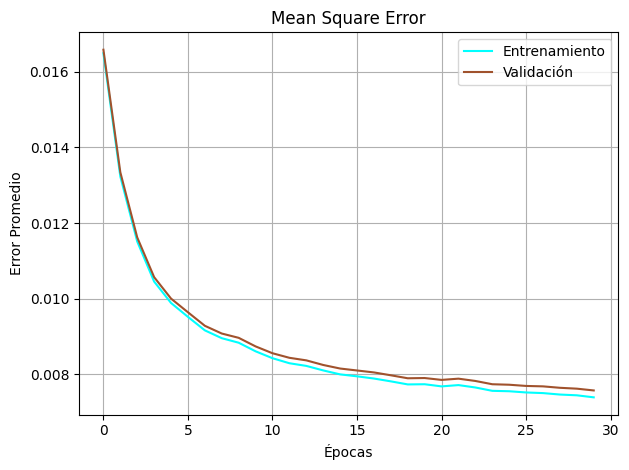

In [40]:
plt.title("Mean Square Error")
plt.xlabel("Épocas")
plt.ylabel("Error Promedio")
plt.plot(range(EPOCHS), train_loss_mean, color='aqua', label='Entrenamiento')
plt.plot(range(EPOCHS), valid_loss_mean, color='sienna', label='Validación')
# plt.plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

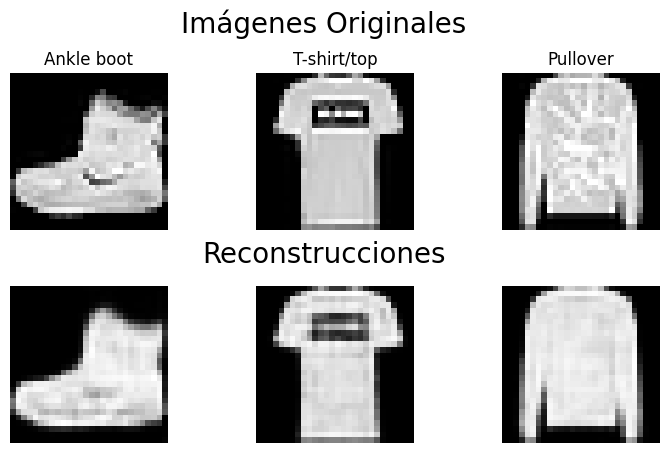

In [49]:
pre_trained_autoencoder.eval()

idxs = [0, 1, 21+6]

fig = plt.figure(figsize=(9, 5))

with torch.no_grad():
    for i, idx in enumerate(idxs):
        image, label = train_set_orig[idx]

        # ---------- Original ----------
        plt.subplot(2, 3, i+1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(class_names[label])
        plt.axis('off')

        # ---------- Reconstrucción ----------
        input_img = image.unsqueeze(0).to(device)
        output_img = pre_trained_autoencoder(input_img)
        output_img = output_img.cpu().squeeze()

        plt.subplot(2, 3, i+4)
        plt.imshow(output_img, cmap='gray')
        plt.axis('off')

# Títulos de filas
fig.text(0.5, 0.93, "Imágenes Originales", ha='center', fontsize=20)
fig.text(0.5, 0.47, "Reconstrucciones", ha='center', fontsize=20)

fig.subplots_adjust(top=0.85, hspace=0.35)
plt.show()


## ** ✅*a) Cantidad de filtros***

- Pasamos de (8,16) a (32,64)



In [ ]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.MSELoss()

# -------- Model --------
n=128
pre_trained_autoencoder_a = AutoencoderConvolutional(n=n, p1=0.2, p2=0.0, filter_num1=32, filter_num2=64, use_bn=True).to(device)

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(pre_trained_autoencoder_a.parameters(), lr=learning_rate)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []

In [ ]:
# OJO! El error en training es el que se imprime al finalizar todos los batches de la época.

EPOCHS = 40
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, pre_trained_autoencoder_a, loss_fn, optimizer)
    train_loss = valid_loop_autoencoder(train_dataloader, pre_trained_autoencoder_a, loss_fn)
    valid_loss = valid_loop_autoencoder(valid_dataloader, pre_trained_autoencoder_a, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
print("Done!")

In [ ]:
plt.title("Mean Square Error")
plt.xlabel("Épocas")
plt.ylabel("Error Promedio")
plt.plot(range(EPOCHS), train_loss_mean, color='blue', label='Entrenamiento')
plt.plot(range(EPOCHS), valid_loss_mean, color='green', label='Validación')
# plt.plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ***b) Modificar kernels/stride/padding***

ks1=5
ks2=5

pad1=2
pad2=2

str1=1
str2=1 (queda igual)


ks3=2
ks4=5

pad3=1
pad4=1 (si no da error de dimensiones)
_____
ks3=3
ks4=5

In [ ]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.MSELoss()

# -------- Model --------
n=128
pre_trained_autoencoder_b = AutoencoderConvolutional(n=n, p1=0.2, p2=0.0, filter_num1=8, filter_num2=16, use_bn=True).to(device)

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(pre_trained_autoencoder_b.parameters(), lr=learning_rate)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []

In [ ]:
# OJO! El error en training es el que se imprime al finalizar todos los batches de la época.

EPOCHS = 30
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, pre_trained_autoencoder_b, loss_fn, optimizer)
    train_loss = valid_loop_autoencoder(train_dataloader, pre_trained_autoencoder_b, loss_fn)
    valid_loss = valid_loop_autoencoder(valid_dataloader, pre_trained_autoencoder_b, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
print("Done!")

In [ ]:
plt.title("Mean Square Error")
plt.xlabel("Épocas")
plt.ylabel("Error Promedio")
plt.plot(range(EPOCHS), train_loss_mean, color='crimson', label='Entrenamiento')
plt.plot(range(EPOCHS), valid_loss_mean, color='green', label='Validación')
# plt.plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ***✅c) Quitar bottleneck***

In [15]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.MSELoss()

# -------- Model --------
n=128
pre_trained_autoencoder_c = AutoencoderConvolutional(n=n, p1=0.2, p2=0.0, filter_num1=8, filter_num2=16, use_bn=False).to(device)

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(pre_trained_autoencoder_c.parameters(), lr=learning_rate)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []

In [33]:
# OJO! El error en training es el que se imprime al finalizar todos los batches de la época.

EPOCHS = 30
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, pre_trained_autoencoder_c, loss_fn, optimizer)
    train_loss = valid_loop_autoencoder(train_dataloader, pre_trained_autoencoder_c, loss_fn)
    valid_loss = valid_loop_autoencoder(valid_dataloader, pre_trained_autoencoder_c, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
print("Done!")

Epoch 1
-------------------------------
loss: 0.177242  [  100/60000]
loss: 0.043972  [10100/60000]
loss: 0.032589  [20100/60000]
loss: 0.024029  [30100/60000]
loss: 0.021066  [40100/60000]
loss: 0.018329  [50100/60000]
Test Error: Avg loss: 0.013684 

Test Error: Avg loss: 0.013783 

Epoch 2
-------------------------------
loss: 0.016134  [  100/60000]
loss: 0.015605  [10100/60000]
loss: 0.014928  [20100/60000]
loss: 0.013585  [30100/60000]
loss: 0.013386  [40100/60000]
loss: 0.012869  [50100/60000]
Test Error: Avg loss: 0.009413 

Test Error: Avg loss: 0.009469 

Epoch 3
-------------------------------
loss: 0.012687  [  100/60000]
loss: 0.011270  [10100/60000]
loss: 0.011574  [20100/60000]
loss: 0.011580  [30100/60000]
loss: 0.011085  [40100/60000]
loss: 0.010715  [50100/60000]
Test Error: Avg loss: 0.007877 

Test Error: Avg loss: 0.007927 

Epoch 4
-------------------------------
loss: 0.010573  [  100/60000]
loss: 0.010642  [10100/60000]
loss: 0.010999  [20100/60000]
loss: 0.0099

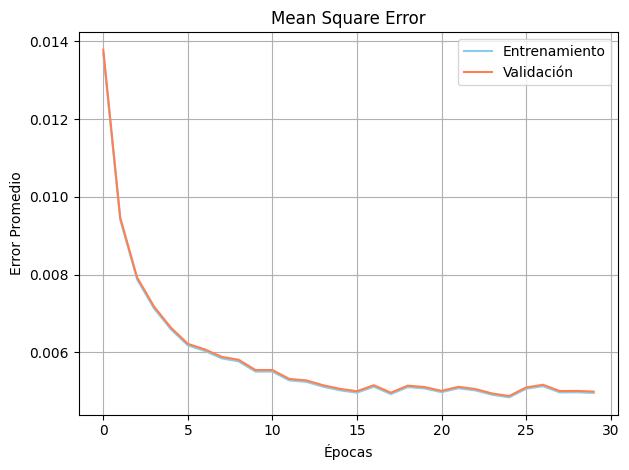

In [34]:
plt.title("Mean Square Error")
plt.xlabel("Épocas")
plt.ylabel("Error Promedio")
plt.plot(range(EPOCHS), train_loss_mean, color='skyblue', label='Entrenamiento')
plt.plot(range(EPOCHS), valid_loss_mean, color='coral', label='Validación')
# plt.plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ***d) Tasa de aprendizaje***

In [ ]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.MSELoss()

# -------- Model --------
n=128
pre_trained_autoencoder_d = AutoencoderConvolutional(n=n, p1=0.2, p2=0.0, filter_num1=8, filter_num2=16, use_bn=True).to(device)

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(pre_trained_autoencoder_d.parameters(), lr=learning_rate)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []

In [ ]:
# OJO! El error en training es el que se imprime al finalizar todos los batches de la época.

EPOCHS = 30
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, pre_trained_autoencoder_d, loss_fn, optimizer)
    train_loss = valid_loop_autoencoder(train_dataloader, pre_trained_autoencoder_d, loss_fn)
    valid_loss = valid_loop_autoencoder(valid_dataloader, pre_trained_autoencoder_d, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
print("Done!")

In [ ]:
plt.title("Mean Square Error")
plt.xlabel("Épocas")
plt.ylabel("Error Promedio")
plt.plot(range(EPOCHS), train_loss_mean, color='gold', label='Entrenamiento')
plt.plot(range(EPOCHS), valid_loss_mean, color='olive', label='Validación')
# plt.plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ***✅e) Dropout***

In [35]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.MSELoss()

# -------- Model --------
n=128
pre_trained_autoencoder_e = AutoencoderConvolutional(n=n, p1=0.4, p2=0.0, filter_num1=8, filter_num2=16, use_bn=True).to(device)

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(pre_trained_autoencoder_e.parameters(), lr=learning_rate)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []

In [36]:
# OJO! El error en training es el que se imprime al finalizar todos los batches de la época.

EPOCHS = 30
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, pre_trained_autoencoder_e, loss_fn, optimizer)
    train_loss = valid_loop_autoencoder(train_dataloader, pre_trained_autoencoder_e, loss_fn)
    valid_loss = valid_loop_autoencoder(valid_dataloader, pre_trained_autoencoder_e, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
print("Done!")

Epoch 1
-------------------------------
loss: 0.187383  [  100/60000]
loss: 0.039174  [10100/60000]
loss: 0.024620  [20100/60000]
loss: 0.021156  [30100/60000]
loss: 0.018297  [40100/60000]
loss: 0.017610  [50100/60000]
Test Error: Avg loss: 0.016066 

Test Error: Avg loss: 0.016166 

Epoch 2
-------------------------------
loss: 0.017029  [  100/60000]
loss: 0.015760  [10100/60000]
loss: 0.015745  [20100/60000]
loss: 0.015370  [30100/60000]
loss: 0.014113  [40100/60000]
loss: 0.014927  [50100/60000]
Test Error: Avg loss: 0.012847 

Test Error: Avg loss: 0.012943 

Epoch 3
-------------------------------
loss: 0.014061  [  100/60000]
loss: 0.013428  [10100/60000]
loss: 0.013942  [20100/60000]
loss: 0.012877  [30100/60000]
loss: 0.012490  [40100/60000]
loss: 0.012085  [50100/60000]
Test Error: Avg loss: 0.011160 

Test Error: Avg loss: 0.011265 

Epoch 4
-------------------------------
loss: 0.013003  [  100/60000]
loss: 0.012020  [10100/60000]
loss: 0.012672  [20100/60000]
loss: 0.0109

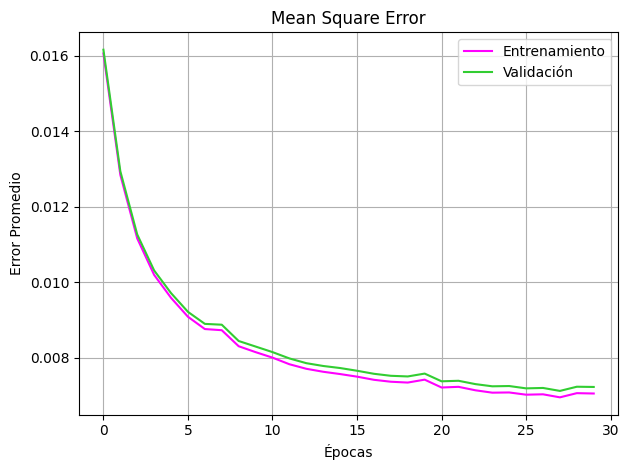

In [37]:
plt.title("Mean Square Error")
plt.xlabel("Épocas")
plt.ylabel("Error Promedio")
plt.plot(range(EPOCHS), train_loss_mean, color='fuchsia', label='Entrenamiento')
plt.plot(range(EPOCHS), valid_loss_mean, color='limegreen', label='Validación')
# plt.plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ***f) Agregar capa lineal antes del bottleneck***

Progressive compression

In [ ]:
# 4.1)
class AutoencoderConvolutional_mod(nn.Module):
    """
    Autoencoder convolucional profundo para imágenes Fashion-MNIST (1x28x28),
    compuesto por un módulo codificador convolucional, un cuello de botella
    opcional completamente conectado y un decodificador convolucional transpuesto.

    Parameters
    ----------
    p1 : float, optional
        Probabilidad de dropout aplicada al final del codificador convolucional.
        Controla el nivel de regularización (default = 0.2).

    p2 : float, optional
        Probabilidad de dropout aplicada en el cuello de botella completamente conectado.
        Permite regularizar el espacio latente. Por defecto no se aplica dropout (default = 0.0).

    n : int, optional
        Dimensión del espacio latente en el cuello de botella fully-connected.
        Determina el grado de compresión de la representación (default = 128).

    filter_num1 : int, optional
        Número de filtros de la primera convolución del encoder.
        Define la profundidad inicial del mapa de características
        (default = 8).

    filter_num2 : int, optional
        Número de filtros de la segunda convolución del encoder.
        Aumenta la capacidad representacional del modelo antes del pooling
        (default = 16).

    ks1 : int, optional
        Tamaño del kernel de la primera convolución del encoder (default = 3).

    ks2 : int, optional
        Tamaño del kernel de la segunda convolución del encoder (default = 3).

    ks3 : int, optional
        Tamaño del kernel de la primera convolución transpuesta del decoder (default = 2).

    ks4 : int, optional
        Tamaño del kernel de la segunda convolución transpuesta del decoder (default = 5).

    str1 : int, optional
        Stride de la primera convolución del encoder (default = 1).

    str2 : int, optional
        Stride de la segunda convolución del encoder (default = 1).

    str3 : int, optional
        Stride de la primera convolución transpuesta del decoder (default = 2).

    str4 : int, optional
        Stride de la segunda convolución transpuesta del decoder (default = 1).

    pad1 : int, optional
        Padding de la primera convolución del encoder (default = 0).

    pad2 : int, optional
        Padding de la segunda convolución del encoder (default = 0).

    pad3 : int, optional
        Padding de la primera convolución transpuesta del decoder (default = 0).

    pad4 : int, optional
        Padding de la segunda convolución transpuesta del decoder (default = 0).

    dil1 : int, optional
        Dilatación de la primera convolución del encoder (default = 1).

    dil2 : int, optional
        Dilatación de la segunda convolución del encoder (default = 1).

    dil3 : int, optional
        Dilatación de la primera convolución transpuesta del decoder (default = 1).

    dil4 : int, optional
        Dilatación de la segunda convolución transpuesta del decoder (default = 1).

    pool_size : tuple of int, optional
        Tamaño del max-pooling aplicado luego de la convolución del encoder.
        Reduce la resolución espacial de los mapas de características
        (default = (2, 2)).

    use_bn : bool, optional
        Indica si se utiliza un cuello de botella lineal completamente conectado.
        Si True, se incluye una capa fully-connected que comprime la representación
        a dimensión n. Si False, se omite el cuello de botella y se mantiene la
        representación convolucional plana (default = True).
    """
    def __init__(self, p1=0.2, p2=0.0, n=128,
                filter_num1=8, filter_num2=16,
                ks1=3, ks2=3, ks3=2, ks4=5,
                str1=1, str2=1, str3=2, str4=1,
                pad1=0, pad2=0, pad3=0, pad4=0,
                dil1=1, dil2=1, dil3=1, dil4=1,
                pool_size=(2,2), use_bn = True):
        super().__init__()

        conv1_out = ((28 + 2*pad1 - dil1*(ks1 - 1) - 1) // str1) + 1
        conv2_out = ((conv1_out + 2*pad2 - dil2*(ks2 - 1) - 1) // str2) + 1

        h_after_pool = conv2_out // pool_size[0]
        w_after_pool = conv2_out // pool_size[1]

        # conv_trans1_out = ((h_after_pool - 1)*str3 - 2*pad3 + dil3*(ks3 - 1) + 1)
        # conv_trans2_out = ((conv_trans1_out - 1)*str4 - 2*pad4 + dil4*(ks4 - 1) + 1)


        self.flat_size = filter_num2 * h_after_pool * w_after_pool

        # -------- Encoder --------
        self.encoder = nn.Sequential(
            nn.Conv2d(1, filter_num1, kernel_size=ks1, stride=str1, padding=pad1, dilation=dil1),  # (1,28,28) -> (filter_num1,conv1_out,conv1_out)
            nn.ReLU(),
            nn.Conv2d(filter_num1, filter_num2, kernel_size=ks2, stride=str2, padding=pad2, dilation=dil2), # (filter_num1,conv1_out,conv1_out) -> (filter_num2,conv2_out,conv2_out)
            nn.ReLU(),
            nn.MaxPool2d(pool_size),             # (filter_num2,h_after_pool,w_after_pool)
            nn.Dropout(p1)
        )

        # -------- Bottleneck MODIFIED --------
        if use_bn:
            self.bottleneck = nn.Sequential(
                nn.Flatten(),                     # (filter_num2,h_after_pool,w_after_pool) -> (flat_size)
                nn.Linear(self.flat_size, 256),   # flat_size -> 256
                nn.ReLU(),
                nn.Linear(256, n),                # 256 -> n
                nn.ReLU(),
                nn.Linear(n, 256),                # n -> 256
                nn.ReLU(),
                nn.Linear(256, self.flat_size),   # 256 -> flat_size
                nn.ReLU()
            )
        else:
            self.bottleneck = nn.Sequential(
                nn.Flatten(),
                nn.Identity()
            )

        # -------- Decoder --------
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (filter_num2, h_after_pool, w_after_pool)),  # (flat_size) -> (filter_num2,h_after_pool,w_after_pool)
            nn.ConvTranspose2d(filter_num2, filter_num1, kernel_size=ks3, stride=str3, padding=pad3, dilation=dil3), # (filter_num2,h_after_pool,w_after_pool) -> (filter_num1,conv_trans1_out,conv_trans1_out)
            nn.ReLU(),
            nn.ConvTranspose2d(filter_num1, 1, kernel_size=ks4, stride=str4, padding=pad4, dilation=dil4), # (filter_num1,conv_trans2_out,conv_trans2_out) -> (1,28,28)
            nn.Sigmoid()                       # salida en [0,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x

In [ ]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.MSELoss()

# -------- Model --------
n=128 # Misma cantidad de neuronas que de pixeles por imagen
pre_trained_autoencoder_f = AutoencoderConvolutional_mod(n=n, filter_num1=8, filter_num2=16).to(device)

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(pre_trained_autoencoder_f.parameters(), lr=learning_rate)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []

In [ ]:
# OJO! El error en training es el que se imprime al finalizar todos los batches de la época.

EPOCHS = 30
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, pre_trained_autoencoder_f, loss_fn, optimizer)
    train_loss = valid_loop_autoencoder(train_dataloader, pre_trained_autoencoder_f, loss_fn)
    valid_loss = valid_loop_autoencoder(valid_dataloader, pre_trained_autoencoder_f, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
print("Done!")

In [ ]:
plt.title("Mean Square Error")
plt.xlabel("Épocas")
plt.ylabel("Error Promedio")
plt.plot(range(EPOCHS), train_loss_mean, color='blueviolet', label='Entrenamiento')
plt.plot(range(EPOCHS), valid_loss_mean, color='springgreen', label='Validación')
# plt.plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Entrenamiento

### ***Autoecoder seleccionado***

In [16]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.MSELoss()

# -------- Model --------
n=128
pre_trained_autoencoder_c = AutoencoderConvolutional(n=n, p1=0.2, p2=0.0, filter_num1=8, filter_num2=16, use_bn=False).to(device)

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(pre_trained_autoencoder_c.parameters(), lr=learning_rate)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []

### ***Loop Clasificador***

In [17]:
def valid_loop_clasiffier(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    valid_loss, valid_correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            # Statistics
            valid_loss += loss_fn(pred, y).item()
            valid_correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    valid_loss /= num_batches
    valid_correct /= size
    print(f"Test Error: \n Accuracy: {(100*valid_correct):>0.1f}%, Avg loss: {valid_loss:>8f} \n")

    return valid_loss, valid_correct

### ***Elección de Clasificador***

#### **✅ *Baseline***

In [18]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set_orig, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set_orig, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.CrossEntropyLoss()

# -------- Model --------
classifier_b = Classifier(autoencoder=pre_trained_autoencoder_c, use_bn=False).to(device)

# Freeze encoder and bottleneck
for param in classifier_b.encoder.parameters():
    param.requires_grad = False

for param in classifier_b.bottleneck.parameters():
    param.requires_grad = False

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, classifier_b.parameters()),
    lr=learning_rate
)

# DEBUG
# for name, p in classifier0.named_parameters():
#     print(name, p.requires_grad)

# -------- Statistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []
train_acc_frac = []
valid_acc_frac = []

In [ ]:
EPOCHS = 80
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, classifier_b, loss_fn, optimizer)
    train_loss, train_acc = valid_loop_clasiffier(train_dataloader, classifier_b, loss_fn)
    valid_loss, valid_acc = valid_loop_clasiffier(valid_dataloader, classifier_b, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
    train_acc_frac.append(train_acc)
    valid_acc_frac.append(valid_acc)
print("Done!")

Epoch 1
-------------------------------
loss: 2.312998  [  100/60000]
loss: 1.082949  [10100/60000]
loss: 0.739875  [20100/60000]
loss: 0.723075  [30100/60000]
loss: 0.686624  [40100/60000]
loss: 0.736224  [50100/60000]
Test Error: 
 Accuracy: 78.2%, Avg loss: 0.563181 

Test Error: 
 Accuracy: 77.3%, Avg loss: 0.577363 

Epoch 2
-------------------------------
loss: 0.721622  [  100/60000]
loss: 0.582651  [10100/60000]
loss: 0.480806  [20100/60000]
loss: 0.547015  [30100/60000]
loss: 0.546707  [40100/60000]
loss: 0.652509  [50100/60000]
Test Error: 
 Accuracy: 83.4%, Avg loss: 0.452925 

Test Error: 
 Accuracy: 82.5%, Avg loss: 0.473307 

Epoch 3
-------------------------------
loss: 0.372028  [  100/60000]
loss: 0.518742  [10100/60000]
loss: 0.393168  [20100/60000]
loss: 0.434634  [30100/60000]
loss: 0.613666  [40100/60000]
loss: 0.378723  [50100/60000]
Test Error: 
 Accuracy: 84.8%, Avg loss: 0.415040 

Test Error: 
 Accuracy: 83.9%, Avg loss: 0.437706 

Epoch 4
--------------------

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Setup baseline", fontsize=20)

# --- Gráfico 1: Cross Entropy Loss ---
axes[0].set_title("Cross Entropy Loss", fontsize=16)
axes[0].set_xlabel("Épocas", fontsize=12)
axes[0].set_ylabel("Pérdida Promedio", fontsize=12)
axes[0].plot(range(EPOCHS), train_loss_mean, color='blue', label='Entrenamiento')
axes[0].plot(range(EPOCHS), valid_loss_mean, color='green', label='Validación')
# axes[0].plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')
axes[0].legend()
axes[0].grid(True)

# --- Gráfico 2: Precisión ---
axes[1].set_title("Accuracy", fontsize=16)
axes[1].set_xlabel("Épocas", fontsize=12)
axes[1].set_ylabel("Precisión", fontsize=12)
axes[1].plot(range(EPOCHS), train_acc_frac, 'o-', c='crimson', label='Entrenamiento')
axes[1].plot(range(EPOCHS), valid_acc_frac, 'o-', c='olive', label='Validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


KeyboardInterrupt



#### ***i) Nº de neuronas en capas ocultas***

In [ ]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set_orig, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set_orig, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.CrossEntropyLoss()

# -------- Model --------
classifier_i = Classifier(autoencoder=pre_trained_autoencoder_c, use_bn=False,n1= 512, n2=256).to(device)

# Freeze encoder and bottleneck
for param in classifier_i.encoder.parameters():
    param.requires_grad = False

for param in classifier_i.bottleneck.parameters():
    param.requires_grad = False

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, classifier_i.parameters()),
    lr=learning_rate
)

# DEBUG
# for name, p in classifier0.named_parameters():
#     print(name, p.requires_grad)

# -------- Statistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []
train_acc_frac = []
valid_acc_frac = []

In [ ]:
EPOCHS = 30
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, classifier_i, loss_fn, optimizer)
    train_loss, train_acc = valid_loop_clasiffier(train_dataloader, classifier_i, loss_fn)
    valid_loss, valid_acc = valid_loop_clasiffier(valid_dataloader, classifier_i, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
    train_acc_frac.append(train_acc)
    valid_acc_frac.append(valid_acc)
print("Done!")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Setup i", fontsize=20)

# --- Gráfico 1: Cross Entropy Loss ---
axes[0].set_title("Cross Entropy Loss", fontsize=16)
axes[0].set_xlabel("Épocas", fontsize=12)
axes[0].set_ylabel("Pérdida Promedio", fontsize=12)
axes[0].plot(range(EPOCHS), train_loss_mean, 's--', color='blue', label='Entrenamiento')
axes[0].plot(range(EPOCHS), valid_loss_mean, 's--', color='green', label='Validación')
# axes[0].plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')
axes[0].legend()
axes[0].grid(True)

# --- Gráfico 2: Precisión ---
axes[1].set_title("Accuracy", fontsize=16)
axes[1].set_xlabel("Épocas", fontsize=12)
axes[1].set_ylabel("Precisión", fontsize=12)
axes[1].plot(range(EPOCHS), train_acc_frac, 'o-', c='crimson', label='Entrenamiento')
axes[1].plot(range(EPOCHS), valid_acc_frac, 'o-', c='olive', label='Validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### ***ii) Optimizador (a SGD)***

In [ ]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set_orig, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set_orig, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.CrossEntropyLoss()

# -------- Model --------
classifier_ii = Classifier(autoencoder=pre_trained_autoencoder_c, use_bn=False).to(device)

# Freeze encoder and bottleneck
for param in classifier_ii.encoder.parameters():
    param.requires_grad = False

for param in classifier_ii.bottleneck.parameters():
    param.requires_grad = False

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, classifier_ii.parameters()),
    lr=learning_rate
)

# DEBUG
# for name, p in classifier0.named_parameters():
#     print(name, p.requires_grad)

# -------- Statistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []
train_acc_frac = []
valid_acc_frac = []

In [ ]:
EPOCHS = 30
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, classifier_ii, loss_fn, optimizer)
    train_loss, train_acc = valid_loop_clasiffier(train_dataloader, classifier_ii, loss_fn)
    valid_loss, valid_acc = valid_loop_clasiffier(valid_dataloader, classifier_ii, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
    train_acc_frac.append(train_acc)
    valid_acc_frac.append(valid_acc)
print("Done!")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Setup ii", fontsize=20)

# --- Gráfico 1: Cross Entropy Loss ---
axes[0].set_title("Cross Entropy Loss", fontsize=16)
axes[0].set_xlabel("Épocas", fontsize=12)
axes[0].set_ylabel("Pérdida Promedio", fontsize=12)
axes[0].plot(range(EPOCHS), train_loss_mean, 's--', color='blue', label='Entrenamiento')
axes[0].plot(range(EPOCHS), valid_loss_mean, 's--', color='green', label='Validación')
# axes[0].plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')
axes[0].legend()
axes[0].grid(True)

# --- Gráfico 2: Precisión ---
axes[1].set_title("Accuracy", fontsize=16)
axes[1].set_xlabel("Épocas", fontsize=12)
axes[1].set_ylabel("Precisión", fontsize=12)
axes[1].plot(range(EPOCHS), train_acc_frac, 'o-', c='crimson', label='Entrenamiento')
axes[1].plot(range(EPOCHS), valid_acc_frac, 'o-', c='olive', label='Validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### ** ✅ *iii) Dropout***

In [46]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set_orig, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set_orig, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.CrossEntropyLoss()

# -------- Model --------
classifier_iii = Classifier(autoencoder=pre_trained_autoencoder_c, use_bn=False, p=0.4).to(device)

# Freeze encoder and bottleneck
for param in classifier_iii.encoder.parameters():
    param.requires_grad = False

for param in classifier_iii.bottleneck.parameters():
    param.requires_grad = False

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, classifier_iii.parameters()),
    lr=learning_rate
)

# DEBUG
# for name, p in classifier0.named_parameters():
#     print(name, p.requires_grad)

# -------- Statistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []
train_acc_frac = []
valid_acc_frac = []

In [47]:
EPOCHS = 30
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, classifier_iii, loss_fn, optimizer)
    train_loss, train_acc = valid_loop_clasiffier(train_dataloader, classifier_iii, loss_fn)
    valid_loss, valid_acc = valid_loop_clasiffier(valid_dataloader, classifier_iii, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
    train_acc_frac.append(train_acc)
    valid_acc_frac.append(valid_acc)
print("Done!")

Epoch 1
-------------------------------
loss: 2.308769  [  100/60000]
loss: 1.033852  [10100/60000]
loss: 0.869241  [20100/60000]
loss: 1.041168  [30100/60000]
loss: 0.731854  [40100/60000]
loss: 0.710098  [50100/60000]
Test Error: 
 Accuracy: 77.8%, Avg loss: 0.569770 

Test Error: 
 Accuracy: 77.1%, Avg loss: 0.583707 

Epoch 2
-------------------------------
loss: 0.706490  [  100/60000]
loss: 0.623906  [10100/60000]
loss: 0.748990  [20100/60000]
loss: 0.514264  [30100/60000]
loss: 0.712209  [40100/60000]
loss: 0.586559  [50100/60000]
Test Error: 
 Accuracy: 80.0%, Avg loss: 0.501096 

Test Error: 
 Accuracy: 79.3%, Avg loss: 0.521045 

Epoch 3
-------------------------------
loss: 0.453522  [  100/60000]
loss: 0.625602  [10100/60000]
loss: 0.614592  [20100/60000]
loss: 0.538631  [30100/60000]
loss: 0.569253  [40100/60000]
loss: 0.475576  [50100/60000]
Test Error: 
 Accuracy: 82.5%, Avg loss: 0.464392 

Test Error: 
 Accuracy: 81.8%, Avg loss: 0.485098 

Epoch 4
--------------------

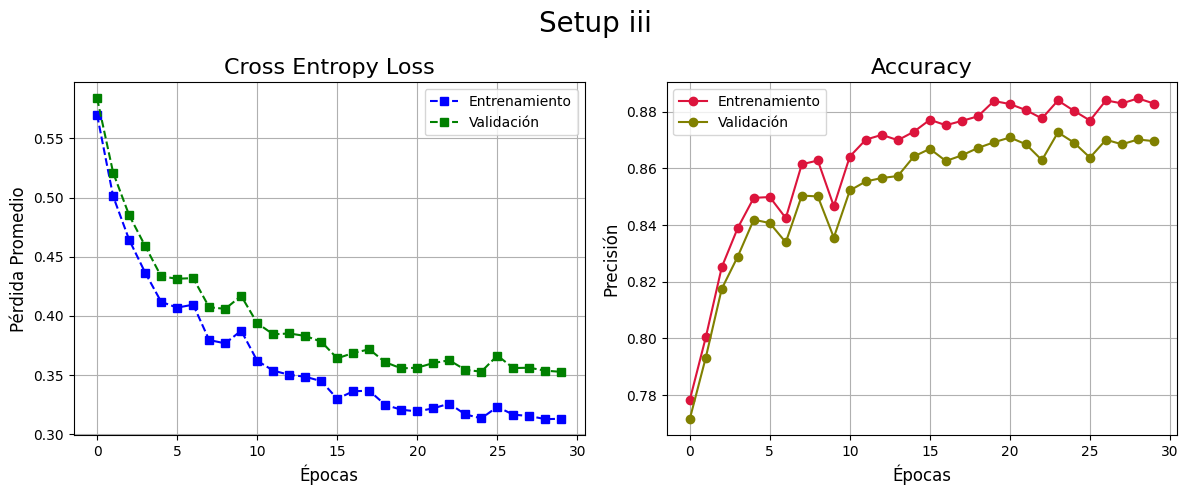

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Setup iii", fontsize=20)

# --- Gráfico 1: Cross Entropy Loss ---
axes[0].set_title("Cross Entropy Loss", fontsize=16)
axes[0].set_xlabel("Épocas", fontsize=12)
axes[0].set_ylabel("Pérdida Promedio", fontsize=12)
axes[0].plot(range(EPOCHS), train_loss_mean, 's--', color='blue', label='Entrenamiento')
axes[0].plot(range(EPOCHS), valid_loss_mean, 's--', color='green', label='Validación')
# axes[0].plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')
axes[0].legend()
axes[0].grid(True)

# --- Gráfico 2: Precisión ---
axes[1].set_title("Accuracy", fontsize=16)
axes[1].set_xlabel("Épocas", fontsize=12)
axes[1].set_ylabel("Precisión", fontsize=12)
axes[1].plot(range(EPOCHS), train_acc_frac, 'o-', c='crimson', label='Entrenamiento')
axes[1].plot(range(EPOCHS), valid_acc_frac, 'o-', c='olive', label='Validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## ✅ Setup 0: Con Pre-entrenamiento y Codificador Freezado (Esquema Original)

In [57]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set_orig, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set_orig, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.CrossEntropyLoss()

# -------- Model --------
classifier0 = Classifier(autoencoder=pre_trained_autoencoder_c, use_bn=False).to(device)

# Freeze encoder and bottleneck
for param in classifier0.encoder.parameters():
    param.requires_grad = False

for param in classifier0.bottleneck.parameters():
    param.requires_grad = False

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, classifier0.parameters()),
    lr=learning_rate
)

# DEBUG
# for name, p in classifier0.named_parameters():
#     print(name, p.requires_grad)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []
train_acc_frac = []
valid_acc_frac = []

In [58]:
EPOCHS = 40
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, classifier0, loss_fn, optimizer)
    train_loss, train_acc = valid_loop_clasiffier(train_dataloader, classifier0, loss_fn)
    valid_loss, valid_acc = valid_loop_clasiffier(valid_dataloader, classifier0, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
    train_acc_frac.append(train_acc)
    valid_acc_frac.append(valid_acc)
print("Done!")

Epoch 1
-------------------------------
loss: 2.303114  [  100/60000]
loss: 1.080635  [10100/60000]
loss: 0.783615  [20100/60000]
loss: 0.631747  [30100/60000]
loss: 0.559987  [40100/60000]
loss: 0.617822  [50100/60000]
Test Error: 
 Accuracy: 79.6%, Avg loss: 0.521884 

Test Error: 
 Accuracy: 78.7%, Avg loss: 0.540659 

Epoch 2
-------------------------------
loss: 0.600427  [  100/60000]
loss: 0.612346  [10100/60000]
loss: 0.544732  [20100/60000]
loss: 0.563378  [30100/60000]
loss: 0.498280  [40100/60000]
loss: 0.558321  [50100/60000]
Test Error: 
 Accuracy: 82.6%, Avg loss: 0.462615 

Test Error: 
 Accuracy: 81.3%, Avg loss: 0.487241 

Epoch 3
-------------------------------
loss: 0.591508  [  100/60000]
loss: 0.502543  [10100/60000]
loss: 0.429321  [20100/60000]
loss: 0.430895  [30100/60000]
loss: 0.604178  [40100/60000]
loss: 0.502644  [50100/60000]
Test Error: 
 Accuracy: 84.6%, Avg loss: 0.418373 

Test Error: 
 Accuracy: 83.3%, Avg loss: 0.448478 

Epoch 4
--------------------

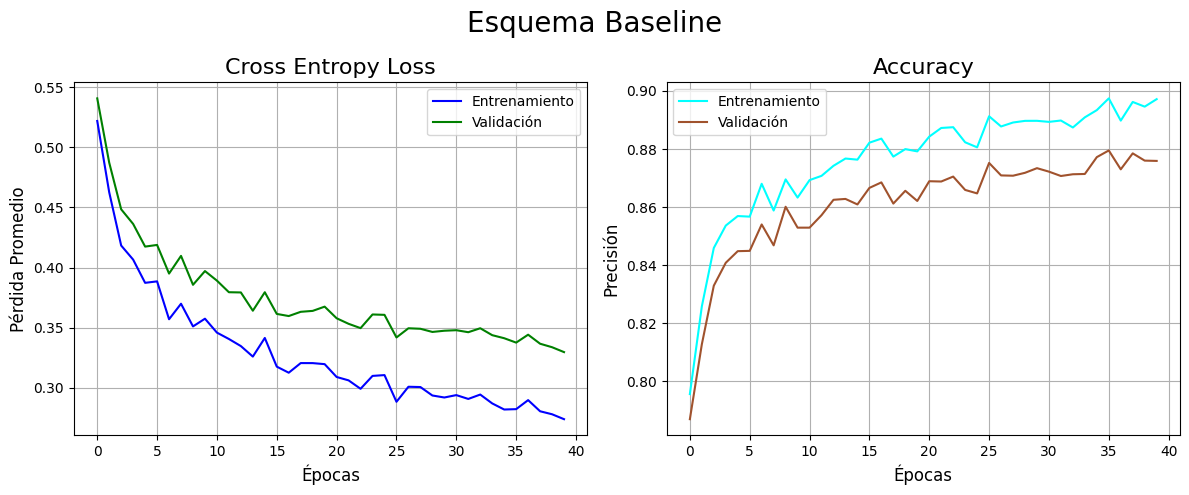

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Esquema Baseline", fontsize=20)

# --- Gráfico 1: Cross Entropy Loss ---
axes[0].set_title("Cross Entropy Loss", fontsize=16)
axes[0].set_xlabel("Épocas", fontsize=12)
axes[0].set_ylabel("Pérdida Promedio", fontsize=12)
axes[0].plot(range(EPOCHS), train_loss_mean, color='blue', label='Entrenamiento')
axes[0].plot(range(EPOCHS), valid_loss_mean, color='green', label='Validación')
# axes[0].plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')
axes[0].legend()
axes[0].grid(True)
    
# --- Gráfico 2: Precisión ---
axes[1].set_title("Accuracy", fontsize=16)
axes[1].set_xlabel("Épocas", fontsize=12)
axes[1].set_ylabel("Precisión", fontsize=12)
axes[1].plot(range(EPOCHS), train_acc_frac, c='aqua', label='Entrenamiento')
axes[1].plot(range(EPOCHS), valid_acc_frac, c='sienna', label='Validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Setup 1: Sin Pre-entrenamiento y Codificador Unfreezeado

In [ ]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set_orig, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set_orig, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.CrossEntropyLoss()

# -------- Model --------
random_autoencoder = AutoencoderConvolutional(n=128).to(device)
classifier1 = Classifier(autoencoder=random_autoencoder).to(device)

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(classifier1.parameters(), lr=learning_rate)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []
train_acc_frac = []
valid_acc_frac = []

In [ ]:
EPOCHS = 40
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, classifier1, loss_fn, optimizer)
    train_loss, train_acc = valid_loop_clasiffier(train_dataloader, classifier1, loss_fn)
    valid_loss, valid_acc = valid_loop_clasiffier(valid_dataloader, classifier1, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
    train_acc_frac.append(train_acc)
    valid_acc_frac.append(valid_acc)
print("Done!")

Epoch 1
-------------------------------
loss: 2.298723  [  100/60000]
loss: 0.723941  [10100/60000]
loss: 0.590200  [20100/60000]
loss: 0.529336  [30100/60000]
loss: 0.647291  [40100/60000]
loss: 0.438244  [50100/60000]
Test Error: 
 Accuracy: 85.9%, Avg loss: 0.389583 

Test Error: 
 Accuracy: 84.9%, Avg loss: 0.412680 

Epoch 2
-------------------------------
loss: 0.453777  [  100/60000]
loss: 0.538495  [10100/60000]
loss: 0.509799  [20100/60000]
loss: 0.379621  [30100/60000]
loss: 0.620647  [40100/60000]
loss: 0.506118  [50100/60000]
Test Error: 
 Accuracy: 88.5%, Avg loss: 0.316475 

Test Error: 
 Accuracy: 87.2%, Avg loss: 0.349857 

Epoch 3
-------------------------------
loss: 0.392137  [  100/60000]
loss: 0.346039  [10100/60000]
loss: 0.459351  [20100/60000]
loss: 0.301473  [30100/60000]
loss: 0.337923  [40100/60000]
loss: 0.390749  [50100/60000]
Test Error: 
 Accuracy: 89.6%, Avg loss: 0.281904 

Test Error: 
 Accuracy: 88.3%, Avg loss: 0.322938 

Epoch 4
--------------------

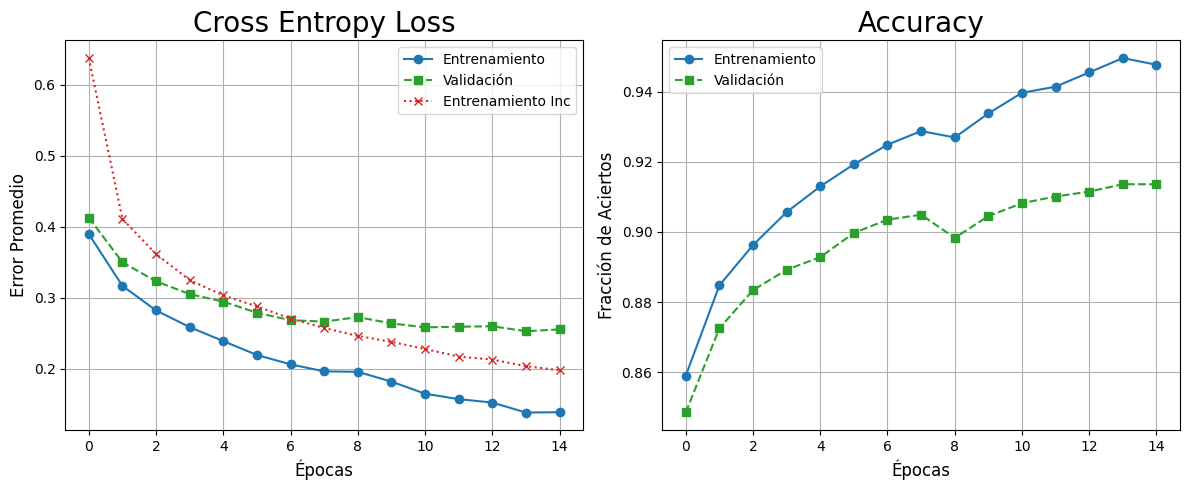

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Setup 1", fontsize=20)

# --- Gráfico 1: Cross Entropy Loss ---
axes[0].set_title("Cross Entropy Loss", fontsize=16)
axes[0].set_xlabel("Épocas", fontsize=12)
axes[0].set_ylabel("Pérdida Promedio", fontsize=12)
axes[0].plot(range(EPOCHS), train_loss_mean, color='blue', label='Entrenamiento')
axes[0].plot(range(EPOCHS), valid_loss_mean, color='green', label='Validación')
# axes[0].plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')
axes[0].legend()
axes[0].grid(True)

# --- Gráfico 2: Precisión ---
axes[1].set_title("Accuracy", fontsize=16)
axes[1].set_xlabel("Épocas", fontsize=12)
axes[1].set_ylabel("Precisión", fontsize=12)
axes[1].plot(range(EPOCHS), train_acc_frac, c='crimson', label='Entrenamiento')
axes[1].plot(range(EPOCHS), valid_acc_frac, c='yellowgreen', label='Validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Setup 2: Con Pre-entrenamiento y Codificador Unfreezeado (Fine Tuning)

In [ ]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set_orig, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set_orig, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.CrossEntropyLoss()

# -------- Model --------
classifier2 = Classifier(autoencoder=pre_trained_autoencoder_c).to(device)

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(classifier2.parameters(), lr=learning_rate)

# -------- Stadistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []
train_acc_frac = []
valid_acc_frac = []

In [ ]:
EPOCHS = 40
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, classifier2, loss_fn, optimizer)
    train_loss, train_acc = valid_loop_clasiffier(train_dataloader, classifier2, loss_fn)
    valid_loss, valid_acc = valid_loop_clasiffier(valid_dataloader, classifier2, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
    train_acc_frac.append(train_acc)
    valid_acc_frac.append(valid_acc)
print("Done!")

Epoch 1
-------------------------------
loss: 2.300538  [  100/60000]
loss: 0.961826  [10100/60000]
loss: 0.545020  [20100/60000]
loss: 0.675745  [30100/60000]
loss: 0.563762  [40100/60000]
loss: 0.493842  [50100/60000]
Test Error: 
 Accuracy: 83.9%, Avg loss: 0.431491 

Test Error: 
 Accuracy: 82.7%, Avg loss: 0.452055 

Epoch 2
-------------------------------
loss: 0.433790  [  100/60000]
loss: 0.482506  [10100/60000]
loss: 0.494911  [20100/60000]
loss: 0.460015  [30100/60000]
loss: 0.300764  [40100/60000]
loss: 0.499505  [50100/60000]
Test Error: 
 Accuracy: 87.2%, Avg loss: 0.349641 

Test Error: 
 Accuracy: 86.0%, Avg loss: 0.383730 

Epoch 3
-------------------------------
loss: 0.581045  [  100/60000]
loss: 0.507265  [10100/60000]
loss: 0.469033  [20100/60000]
loss: 0.512321  [30100/60000]
loss: 0.525540  [40100/60000]
loss: 0.283334  [50100/60000]
Test Error: 
 Accuracy: 88.5%, Avg loss: 0.313875 

Test Error: 
 Accuracy: 86.7%, Avg loss: 0.357173 

Epoch 4
--------------------

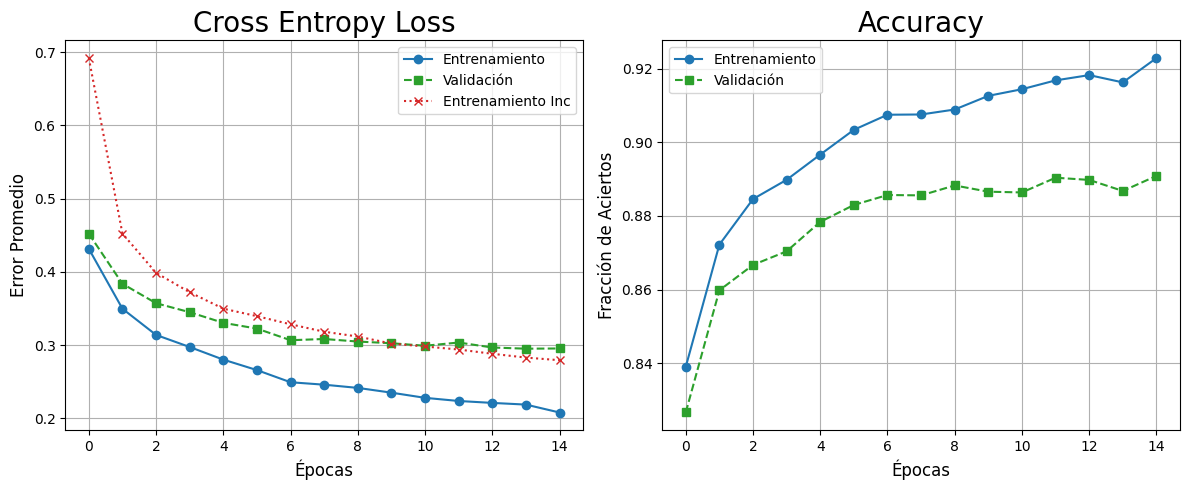

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Esquema 2", fontsize=20)

# --- Gráfico 1: Cross Entropy Loss ---
axes[0].set_title("Cross Entropy Loss", fontsize=16)
axes[0].set_xlabel("Épocas", fontsize=12)
axes[0].set_ylabel("Pérdida Promedio", fontsize=12)
axes[0].plot(range(EPOCHS), train_loss_mean, color='blue', label='Entrenamiento')
axes[0].plot(range(EPOCHS), valid_loss_mean, color='green', label='Validación')
# axes[0].plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')
axes[0].legend()
axes[0].grid(True)

# --- Gráfico 2: Precisión ---
axes[1].set_title("Accuracy", fontsize=16)
axes[1].set_xlabel("Épocas", fontsize=12)
axes[1].set_ylabel("Precisión", fontsize=12)
axes[1].plot(range(EPOCHS), train_acc_frac, c='blueviolet', label='Entrenamiento')
axes[1].plot(range(EPOCHS), valid_acc_frac, c='springgreen', label='Validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**(Modificado POST final)**

## ✅ Setup 3: Sin Pre-entrenamiento y Codificador Freezeado

In [19]:
# -------- Dataloaders --------
train_dataloader = DataLoader(train_set_orig, batch_size=100, shuffle = True)
valid_dataloader = DataLoader(valid_set_orig, batch_size=100, shuffle = False)

# -------- Loss Function --------
loss_fn = nn.CrossEntropyLoss()

# -------- Model --------
random_autoencoder = AutoencoderConvolutional(n=128).to(device)
classifier3 = Classifier(autoencoder=random_autoencoder).to(device)

# Freeze encoder and bottleneck
for param in classifier3.encoder.parameters():
    param.requires_grad = False

for param in classifier3.bottleneck.parameters():
    param.requires_grad = False

# -------- Optimizer --------
learning_rate = 1e-3
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, classifier3.parameters()),
    lr=learning_rate
)

# DEBUG
# for name, p in classifier3.named_parameters():
#     print(name, p.requires_grad)

# -------- Statistics --------
train_loss_mean = []
train_inc_loss_mean = []
valid_loss_mean = []
train_acc_frac = []
valid_acc_frac = []

In [20]:
EPOCHS = 40
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    train_inc_loss = train_loop(train_dataloader, classifier3, loss_fn, optimizer)
    train_loss, train_acc = valid_loop_clasiffier(train_dataloader, classifier3, loss_fn)
    valid_loss, valid_acc = valid_loop_clasiffier(valid_dataloader, classifier3, loss_fn)

    train_inc_loss_mean.append(train_inc_loss)
    train_loss_mean.append(train_loss)
    valid_loss_mean.append(valid_loss)
    train_acc_frac.append(train_acc)
    valid_acc_frac.append(valid_acc)
print("Done!")

Epoch 1
-------------------------------
loss: 2.302475  [  100/60000]
loss: 0.838858  [10100/60000]
loss: 0.746897  [20100/60000]
loss: 0.768888  [30100/60000]
loss: 0.632249  [40100/60000]
loss: 0.517214  [50100/60000]
Test Error: 
 Accuracy: 79.3%, Avg loss: 0.520926 

Test Error: 
 Accuracy: 78.8%, Avg loss: 0.536871 

Epoch 2
-------------------------------
loss: 0.479783  [  100/60000]
loss: 0.444429  [10100/60000]
loss: 0.609209  [20100/60000]
loss: 0.499465  [30100/60000]
loss: 0.589735  [40100/60000]
loss: 0.543789  [50100/60000]
Test Error: 
 Accuracy: 83.3%, Avg loss: 0.438328 

Test Error: 
 Accuracy: 82.8%, Avg loss: 0.459320 

Epoch 3
-------------------------------
loss: 0.453675  [  100/60000]
loss: 0.391721  [10100/60000]
loss: 0.343160  [20100/60000]
loss: 0.469305  [30100/60000]
loss: 0.345756  [40100/60000]
loss: 0.346271  [50100/60000]
Test Error: 
 Accuracy: 85.9%, Avg loss: 0.395054 

Test Error: 
 Accuracy: 84.7%, Avg loss: 0.424790 

Epoch 4
--------------------

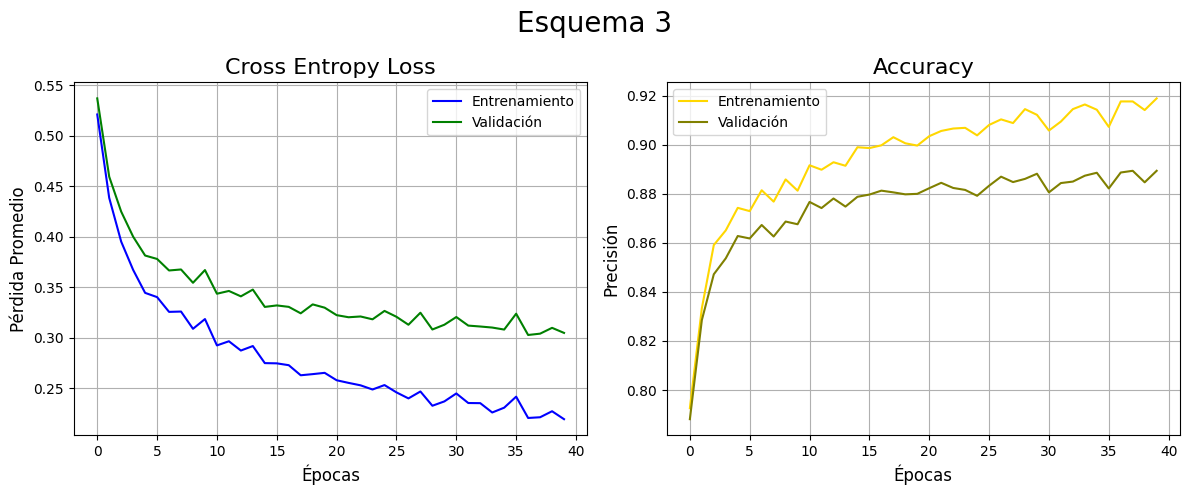

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Esquema 3", fontsize=20)

# --- Gráfico 1: Cross Entropy Loss ---
axes[0].set_title("Cross Entropy Loss", fontsize=16)
axes[0].set_xlabel("Épocas", fontsize=12)
axes[0].set_ylabel("Pérdida Promedio", fontsize=12)
axes[0].plot(range(EPOCHS), train_loss_mean, color='blue', label='Entrenamiento')
axes[0].plot(range(EPOCHS), valid_loss_mean, color='green', label='Validación')
# axes[0].plot(range(EPOCHS), train_inc_loss_mean, 'x:', color='tab:red', label='Entrenamiento Inc')
axes[0].legend()
axes[0].grid(True)

# --- Gráfico 2: Precisión ---
axes[1].set_title("Accuracy", fontsize=16)
axes[1].set_xlabel("Épocas", fontsize=12)
axes[1].set_ylabel("Precisión", fontsize=12)
axes[1].plot(range(EPOCHS), train_acc_frac, c='gold', label='Entrenamiento')
axes[1].plot(range(EPOCHS), valid_acc_frac, c='olive', label='Validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Matriz de confusión

In [ ]:
# %pip install seaborn

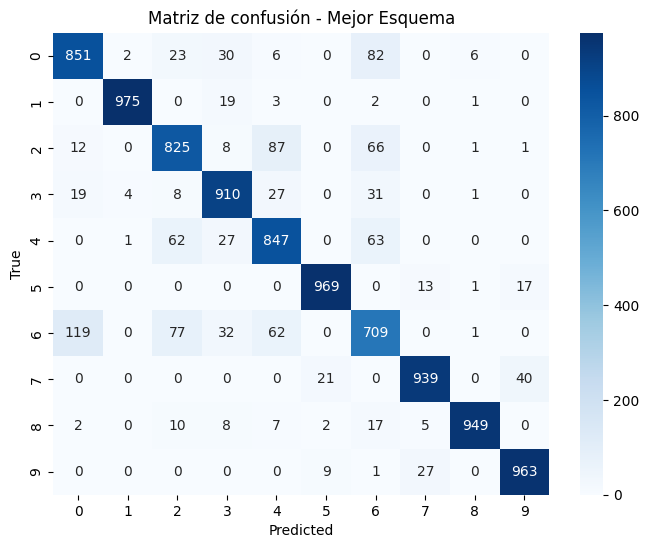

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Put model in evaluation mode
classifier3.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in valid_dataloader:
        X, y = X.to(device), y.to(device)
        outputs = classifier3(X)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Matriz de confusión - Mejor Esquema")
plt.show()